In [22]:
import pandas as pd
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)

# 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签

# 读取数据集
df = pd.read_csv('Seattle_Hotels.csv', encoding="UTF-8")

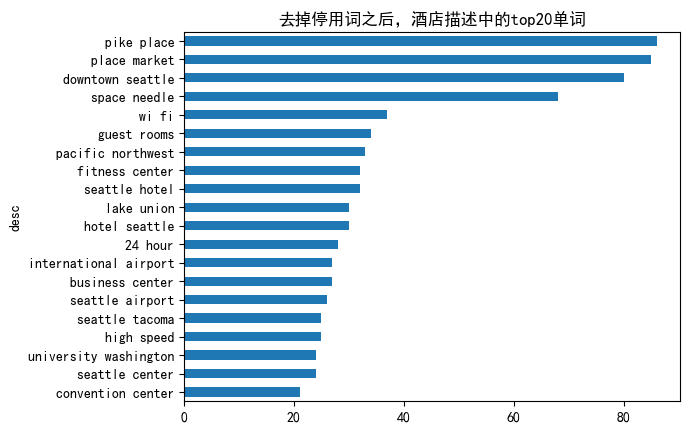

In [24]:
# 创建英文停用词列表
ENGLISH_STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your',
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it',
    "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this',
    'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while',
    'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above',
    'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once',
    'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some',
    'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don',
    "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn',
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn',
    "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't",
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}
# 得到酒店描述中n-gram特征中的topK个
def get_top_n_words(corpus, n=1, k=20):
    # 统计ngram词频矩阵，使用自定义停用词列表
    vec = CountVectorizer(ngram_range=(n, n), stop_words=list(ENGLISH_STOPWORDS)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # 按照词频大小从大到小排序
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:k]

n1 = 2
k1 = 20
common_words = get_top_n_words(df['desc'], n1, k1)
df1 = pd.DataFrame(common_words, columns=['desc', 'count'])
df1.groupby('desc').sum()['count'].sort_values().plot(kind='barh', title=f'去掉停用词之后，酒店描述中的top{k1}单词')
plt.show()


In [25]:
import nltk
nltk.download('stopwords', 'E:/projects/python/AI/bigmodel-app-zhihu/04-Embedding/hotel_recommendation')

[nltk_data] Downloading package stopwords to
[nltk_data]     E:/projects/python/AI/bigmodel-app-
[nltk_data]     zhihu/04-Embedding/hotel_recommendation...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
# 文本预处理
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
# 使用自定义的英文停用词替代nltk的stopwords
STOPWORDS = ENGLISH_STOPWORDS
# 文本清洗
def clean_text(text):
    # 全部小写
    text = text.lower()
    # 空格替换特殊符号，比如标点
    text = REPLACE_BY_SPACE_RE.sub(' ', text)
    # 移除坏掉的字符
    text = BAD_SYMBOLS_RE.sub('', text)
    # 文本去掉停用词
    text = ' '.join(word for word in text.split() if word not in STOPWORDS)
    return text

# 对desc标签清洗，apply针对某列
df['desc_cleaned'] = df['desc'].apply(clean_text)
# print(df['desc_cleaned'].head())


<>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
C:\Users\admin\AppData\Local\Temp\ipykernel_3288\2264292318.py:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')


In [30]:
# 建模
# df.set_index('name', inplace = True)
# print("DataFrame的列名:")
# print(df.columns.tolist())
# 使用TF-IDF提取文本特征，使用自定义停用词列表, 1元特征（1000） + 2元特征（1200） + 3元特征（1147）=3347
tf = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=0.01, stop_words=list(ENGLISH_STOPWORDS))
# 针对desc_clean提取tfidf
tfidf_matrix = tf.fit_transform(df['desc_cleaned'])
print('TFIDF feature names:')
#print(tf.get_feature_names_out())
print(len(tf.get_feature_names_out()))
print('tfidf_matrix:')

KeyError: "None of ['name'] are in the columns"

In [35]:
# 计算酒店之间的余弦相似度
cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)
print(cosine_similarities)
print(cosine_similarities.shape)
indices = pd.Series(df.index)

[[1.         0.03923426 0.0986154  ... 0.04852358 0.0229397  0.02704312]
 [0.03923426 1.         0.05845102 ... 0.06106913 0.01515334 0.03571532]
 [0.0986154  0.05845102 1.         ... 0.0861429  0.04181626 0.05045885]
 ...
 [0.04852358 0.06106913 0.0861429  ... 1.         0.05756747 0.03898101]
 [0.0229397  0.01515334 0.04181626 ... 0.05756747 1.         0.01747434]
 [0.02704312 0.03571532 0.05045885 ... 0.03898101 0.01747434 1.        ]]
(152, 152)


In [38]:
 # 基于相似度矩阵和指定的酒店name，推荐TOP10酒店
def recommendations(name, cosine_similarities = cosine_similarities):
    recommended_hotels = []
    # 找到想要查询酒店名称的idx
    idx = indices[indices == name].index[0]
    print('idx=', idx)
    # 对于idx酒店的余弦相似度向量按照从大到小进行排序
    score_series = pd.Series(cosine_similarities[idx]).sort_values(ascending = False)
    # 取相似度最大的前10个（除了自己以外）
    top_10_indexes = list(score_series.iloc[1:11].index)
    # 放到推荐列表中
    for i in top_10_indexes:
        recommended_hotels.append(list(df.index)[i])
    return recommended_hotels
print(recommendations('Hilton Seattle Airport & Conference Center'))
print(recommendations('The Bacon Mansion Bed and Breakfast'))

idx= 49
['Embassy Suites by Hilton Seattle Tacoma International Airport', 'DoubleTree by Hilton Hotel Seattle Airport', 'Seattle Airport Marriott', 'Four Points by Sheraton Downtown Seattle Center', 'Motel 6 Seattle Sea-Tac Airport South', 'Hampton Inn Seattle/Southcenter', 'Radisson Hotel Seattle Airport', 'Knights Inn Tukwila', 'Home2 Suites by Hilton Seattle Airport', 'Hotel Hotel']
idx= 116
['11th Avenue Inn Bed and Breakfast', 'Shafer Baillie Mansion Bed & Breakfast', 'Gaslight Inn', 'Bed and Breakfast Inn Seattle', 'Chittenden House Bed and Breakfast', 'Hyatt House Seattle', 'Mozart Guest House', 'Silver Cloud Hotel - Seattle Broadway', 'WorldMark Seattle - The Camlin', 'Pensione Nichols Bed and Breakfast']
